In [17]:
## Data Collection

import nltk
nltk.download("gutenberg")

[nltk_data] Downloading package gutenberg to
[nltk_data]     C:\Users\offic\AppData\Roaming\nltk_data...
[nltk_data]   Package gutenberg is already up-to-date!


True

In [18]:
## Load Data

from nltk.corpus import gutenberg
import pandas as pd

data = gutenberg.raw("shakespeare-hamlet.txt")
type(data)

str

In [19]:
## Save Dataset

with open("hamlet.txt", "w") as file:
    file.write(data)

In [20]:
## Data preprocessing

import numpy as np
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.model_selection import train_test_split

In [21]:
with open("hamlet.txt", "r") as file:
    text = file.read().lower()

tokenizer = Tokenizer()
tokenizer.fit_on_texts([text]) ## Assigns index to the vocabulary (1 based)
total_words = len(tokenizer.word_index)+1 ## word index starts from 1 so add 1 for 0 index
total_words

4818

In [22]:
tokenizer.word_index ## Word : index

{'the': 1,
 'and': 2,
 'to': 3,
 'of': 4,
 'i': 5,
 'you': 6,
 'a': 7,
 'my': 8,
 'it': 9,
 'in': 10,
 'that': 11,
 'ham': 12,
 'is': 13,
 'not': 14,
 'his': 15,
 'this': 16,
 'with': 17,
 'your': 18,
 'but': 19,
 'for': 20,
 'me': 21,
 'lord': 22,
 'as': 23,
 'what': 24,
 'he': 25,
 'be': 26,
 'so': 27,
 'him': 28,
 'haue': 29,
 'king': 30,
 'will': 31,
 'no': 32,
 'our': 33,
 'we': 34,
 'on': 35,
 'are': 36,
 'if': 37,
 'all': 38,
 'then': 39,
 'shall': 40,
 'by': 41,
 'thou': 42,
 'come': 43,
 'or': 44,
 'hamlet': 45,
 'good': 46,
 'do': 47,
 'hor': 48,
 'her': 49,
 'let': 50,
 'now': 51,
 'thy': 52,
 'how': 53,
 'more': 54,
 'they': 55,
 'from': 56,
 'enter': 57,
 'at': 58,
 'was': 59,
 'oh': 60,
 'like': 61,
 'most': 62,
 'there': 63,
 'well': 64,
 'know': 65,
 'selfe': 66,
 'would': 67,
 'them': 68,
 'loue': 69,
 'may': 70,
 "'tis": 71,
 'vs': 72,
 'sir': 73,
 'qu': 74,
 'which': 75,
 'did': 76,
 'why': 77,
 'laer': 78,
 'giue': 79,
 'thee': 80,
 'ile': 81,
 'must': 82,
 'hath': 

In [23]:
tokenizer.texts_to_sequences([text]) ## Converts words to its index assigned

[[1,
  687,
  4,
  45,
  41,
  1886,
  1887,
  1888,
  1180,
  1889,
  1890,
  1891,
  57,
  407,
  2,
  1181,
  177,
  1892,
  407,
  1182,
  63,
  408,
  162,
  377,
  21,
  247,
  882,
  18,
  66,
  451,
  224,
  248,
  1,
  30,
  408,
  407,
  451,
  25,
  408,
  6,
  43,
  62,
  1893,
  96,
  18,
  566,
  451,
  71,
  51,
  1894,
  567,
  378,
  80,
  3,
  273,
  1181,
  408,
  20,
  16,
  1895,
  114,
  379,
  71,
  883,
  491,
  2,
  5,
  92,
  688,
  58,
  144,
  346,
  29,
  6,
  108,
  568,
  884,
  408,
  14,
  7,
  885,
  1896,
  346,
  64,
  380,
  37,
  6,
  47,
  689,
  120,
  2,
  347,
  1,
  1897,
  4,
  8,
  257,
  492,
  68,
  87,
  149,
  57,
  120,
  2,
  347,
  408,
  5,
  117,
  5,
  139,
  68,
  247,
  1182,
  63,
  48,
  205,
  3,
  16,
  409,
  140,
  2,
  1898,
  348,
  3,
  1,
  493,
  408,
  79,
  6,
  46,
  124,
  140,
  125,
  1899,
  322,
  1183,
  121,
  83,
  1900,
  6,
  1901,
  407,
  258,
  8,
  494,
  79,
  6,
  380,
  218,
  408,
  140,
  1902,
  

In [24]:
## Create Input Sequences
input_sequence = []
for line in text.split('\n'):
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[:i+1]
        input_sequence.append(n_gram_sequence)


In [25]:
input_sequence

[[1, 687],
 [1, 687, 4],
 [1, 687, 4, 45],
 [1, 687, 4, 45, 41],
 [1, 687, 4, 45, 41, 1886],
 [1, 687, 4, 45, 41, 1886, 1887],
 [1, 687, 4, 45, 41, 1886, 1887, 1888],
 [1180, 1889],
 [1180, 1889, 1890],
 [1180, 1889, 1890, 1891],
 [57, 407],
 [57, 407, 2],
 [57, 407, 2, 1181],
 [57, 407, 2, 1181, 177],
 [57, 407, 2, 1181, 177, 1892],
 [407, 1182],
 [407, 1182, 63],
 [408, 162],
 [408, 162, 377],
 [408, 162, 377, 21],
 [408, 162, 377, 21, 247],
 [408, 162, 377, 21, 247, 882],
 [18, 66],
 [451, 224],
 [451, 224, 248],
 [451, 224, 248, 1],
 [451, 224, 248, 1, 30],
 [408, 407],
 [451, 25],
 [408, 6],
 [408, 6, 43],
 [408, 6, 43, 62],
 [408, 6, 43, 62, 1893],
 [408, 6, 43, 62, 1893, 96],
 [408, 6, 43, 62, 1893, 96, 18],
 [408, 6, 43, 62, 1893, 96, 18, 566],
 [451, 71],
 [451, 71, 51],
 [451, 71, 51, 1894],
 [451, 71, 51, 1894, 567],
 [451, 71, 51, 1894, 567, 378],
 [451, 71, 51, 1894, 567, 378, 80],
 [451, 71, 51, 1894, 567, 378, 80, 3],
 [451, 71, 51, 1894, 567, 378, 80, 3, 273],
 [451, 71

In [26]:
## Pad Sequence
max_sequence_len = max(len(x) for x in input_sequence)

In [27]:
max_sequence_len

14

In [28]:
type(input_sequence)

list

In [29]:
input_sequence = np.array(pad_sequences(input_sequence, maxlen=max_sequence_len, padding="pre"))

In [30]:
input_sequence.shape

(25732, 14)

In [31]:
## Create predictors (X) and labels (y)
import tensorflow as tf
X,y = input_sequence[:,:-1], input_sequence[:,-1] # We basically teaching model to learn sequence of words

In [32]:
# Convert y into category

y = tf.keras.utils.to_categorical(y, num_classes=total_words) ## OHE for whole vocab because at last we will apply softmax function which will generate probablilites for all vocab

In [33]:
y

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [34]:
## Train-test split

X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.2)

## Training

In [35]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Embedding, Dropout, Dense

model = Sequential()
model.add(
    Embedding(input_dim=total_words, output_dim=100, input_length=max_sequence_len-1)
)

# Embedding(
#     vocab_size,
#     100,
#     mask_zero=True # Tells LSTM to ignore 0 (paddings) in the vectors
# )

model.add(
    LSTM(150, return_sequences=True) ## Change to GRU
)

model.add(
    Dropout(0.2)
)

model.add(LSTM(100)) ## Change to GRU

model.add(
    Dense(total_words, activation = "softmax")
)

model.compile(loss="categorical_crossentropy", optimizer= "adam", metrics=["accuracy"])


In [36]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 13, 100)           481800    
                                                                 
 lstm (LSTM)                 (None, 13, 150)           150600    
                                                                 
 dropout (Dropout)           (None, 13, 150)           0         
                                                                 
 lstm_1 (LSTM)               (None, 100)               100400    
                                                                 
 dense (Dense)               (None, 4818)              486618    
                                                                 
Total params: 1219418 (4.65 MB)
Trainable params: 1219418 (4.65 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [37]:
X_train.shape, y_train.shape, X_test.shape, y_test.shape

((20585, 13), (20585, 4818), (5147, 13), (5147, 4818))

In [38]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(patience=20, monitor="val_loss", restore_best_weights=True)

In [39]:
history = model.fit(X_train, y_train, epochs=100, callbacks=[early_stopping] ,validation_data=(X_test, y_test), verbose=1)

Epoch 1/100


644/644 [==============================] - 34s 39ms/step - loss: 6.9265 - accuracy: 0.0335 - val_loss: 6.7074 - val_accuracy: 0.0346
Epoch 2/100
644/644 [==============================] - 18s 28ms/step - loss: 6.4880 - accuracy: 0.0378 - val_loss: 6.8164 - val_accuracy: 0.0381
Epoch 3/100
644/644 [==============================] - 19s 30ms/step - loss: 6.3594 - accuracy: 0.0448 - val_loss: 6.8370 - val_accuracy: 0.0462
Epoch 4/100
644/644 [==============================] - 19s 29ms/step - loss: 6.2245 - accuracy: 0.0517 - val_loss: 6.8536 - val_accuracy: 0.0482
Epoch 5/100
644/644 [==============================] - 19s 29ms/step - loss: 6.0824 - accuracy: 0.0556 - val_loss: 6.8914 - val_accuracy: 0.0521
Epoch 6/100
644/644 [==============================] - 20s 31ms/step - loss: 5.9412 - accuracy: 0.0608 - val_loss: 6.9276 - val_accuracy: 0.0604
Epoch 7/100
644/644 [==============================] - 19s 30ms/step - loss: 5.8031 - accuracy: 0.0679 - val_loss: 6.9591 - val_

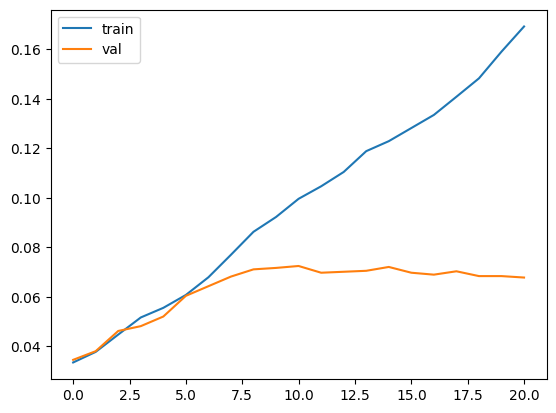

In [45]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train','val'])

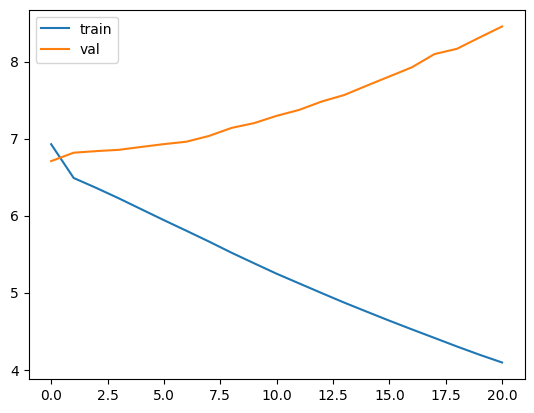

In [46]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train','val'])

## Prediction

In [40]:
# Function to predict the next word
def predict_next_word(model, tokenizer, text, max_sequence_len):
    token_list = tokenizer.texts_to_sequences([text])[0]
    if len(token_list) >= max_sequence_len:
        token_list = token_list[-(max_sequence_len-1):]  # Ensure the sequence length matches max_sequence_len-1
    token_list = pad_sequences([token_list], maxlen=max_sequence_len-1, padding='pre')
    predicted = model.predict(token_list, verbose=0)
    predicted_word_index = np.argmax(predicted, axis=1)
    for word, index in tokenizer.word_index.items():
        if index == predicted_word_index:
            return word
    return None

In [41]:
input_text="oh my"
print(f"Input text:{input_text}")
max_sequence_len=model.input_shape[1]+1
next_word=predict_next_word(model,tokenizer,input_text,max_sequence_len)
print(f"Next Word Prediction:{next_word}")

Input text:oh my
Next Word Prediction:the


In [42]:
model.save("LSTM_word_predicting.h5")

d:\AIML Material\venv\lib\site-packages\keras\src\engine\training.py:3103: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


In [43]:
import pickle
with open("tokenizer.pickle", "wb") as file:
    pickle.dump(tokenizer, file, protocol=pickle.HIGHEST_PROTOCOL)